# Data Augmentation Experiments

This notebook compares different data augmentation strategies and their impact on model performance.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

DATA_DIR = Path('../data/flowers')
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

Using device: cpu


In [2]:
# Define different augmentation strategies
augmentation_strategies = {
    'baseline': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD)
    ]),
    
    'light_augmentation': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD)
    ]),
    
    'medium_augmentation': transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(20),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD)
    ]),
    
    'heavy_augmentation': transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(30),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD)
    ]),
    
    'extreme_augmentation': transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.5, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(45),
        transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5, hue=0.2),
        transforms.RandomAffine(degrees=0, translate=(0.2, 0.2)),
        transforms.RandomPerspective(distortion_scale=0.2, p=0.5),
        transforms.RandomErasing(p=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD)
    ])
}

print("Augmentation strategies defined:")
for name in augmentation_strategies.keys():
    print(f"  - {name}")

Augmentation strategies defined:
  - baseline
  - light_augmentation
  - medium_augmentation
  - heavy_augmentation
  - extreme_augmentation


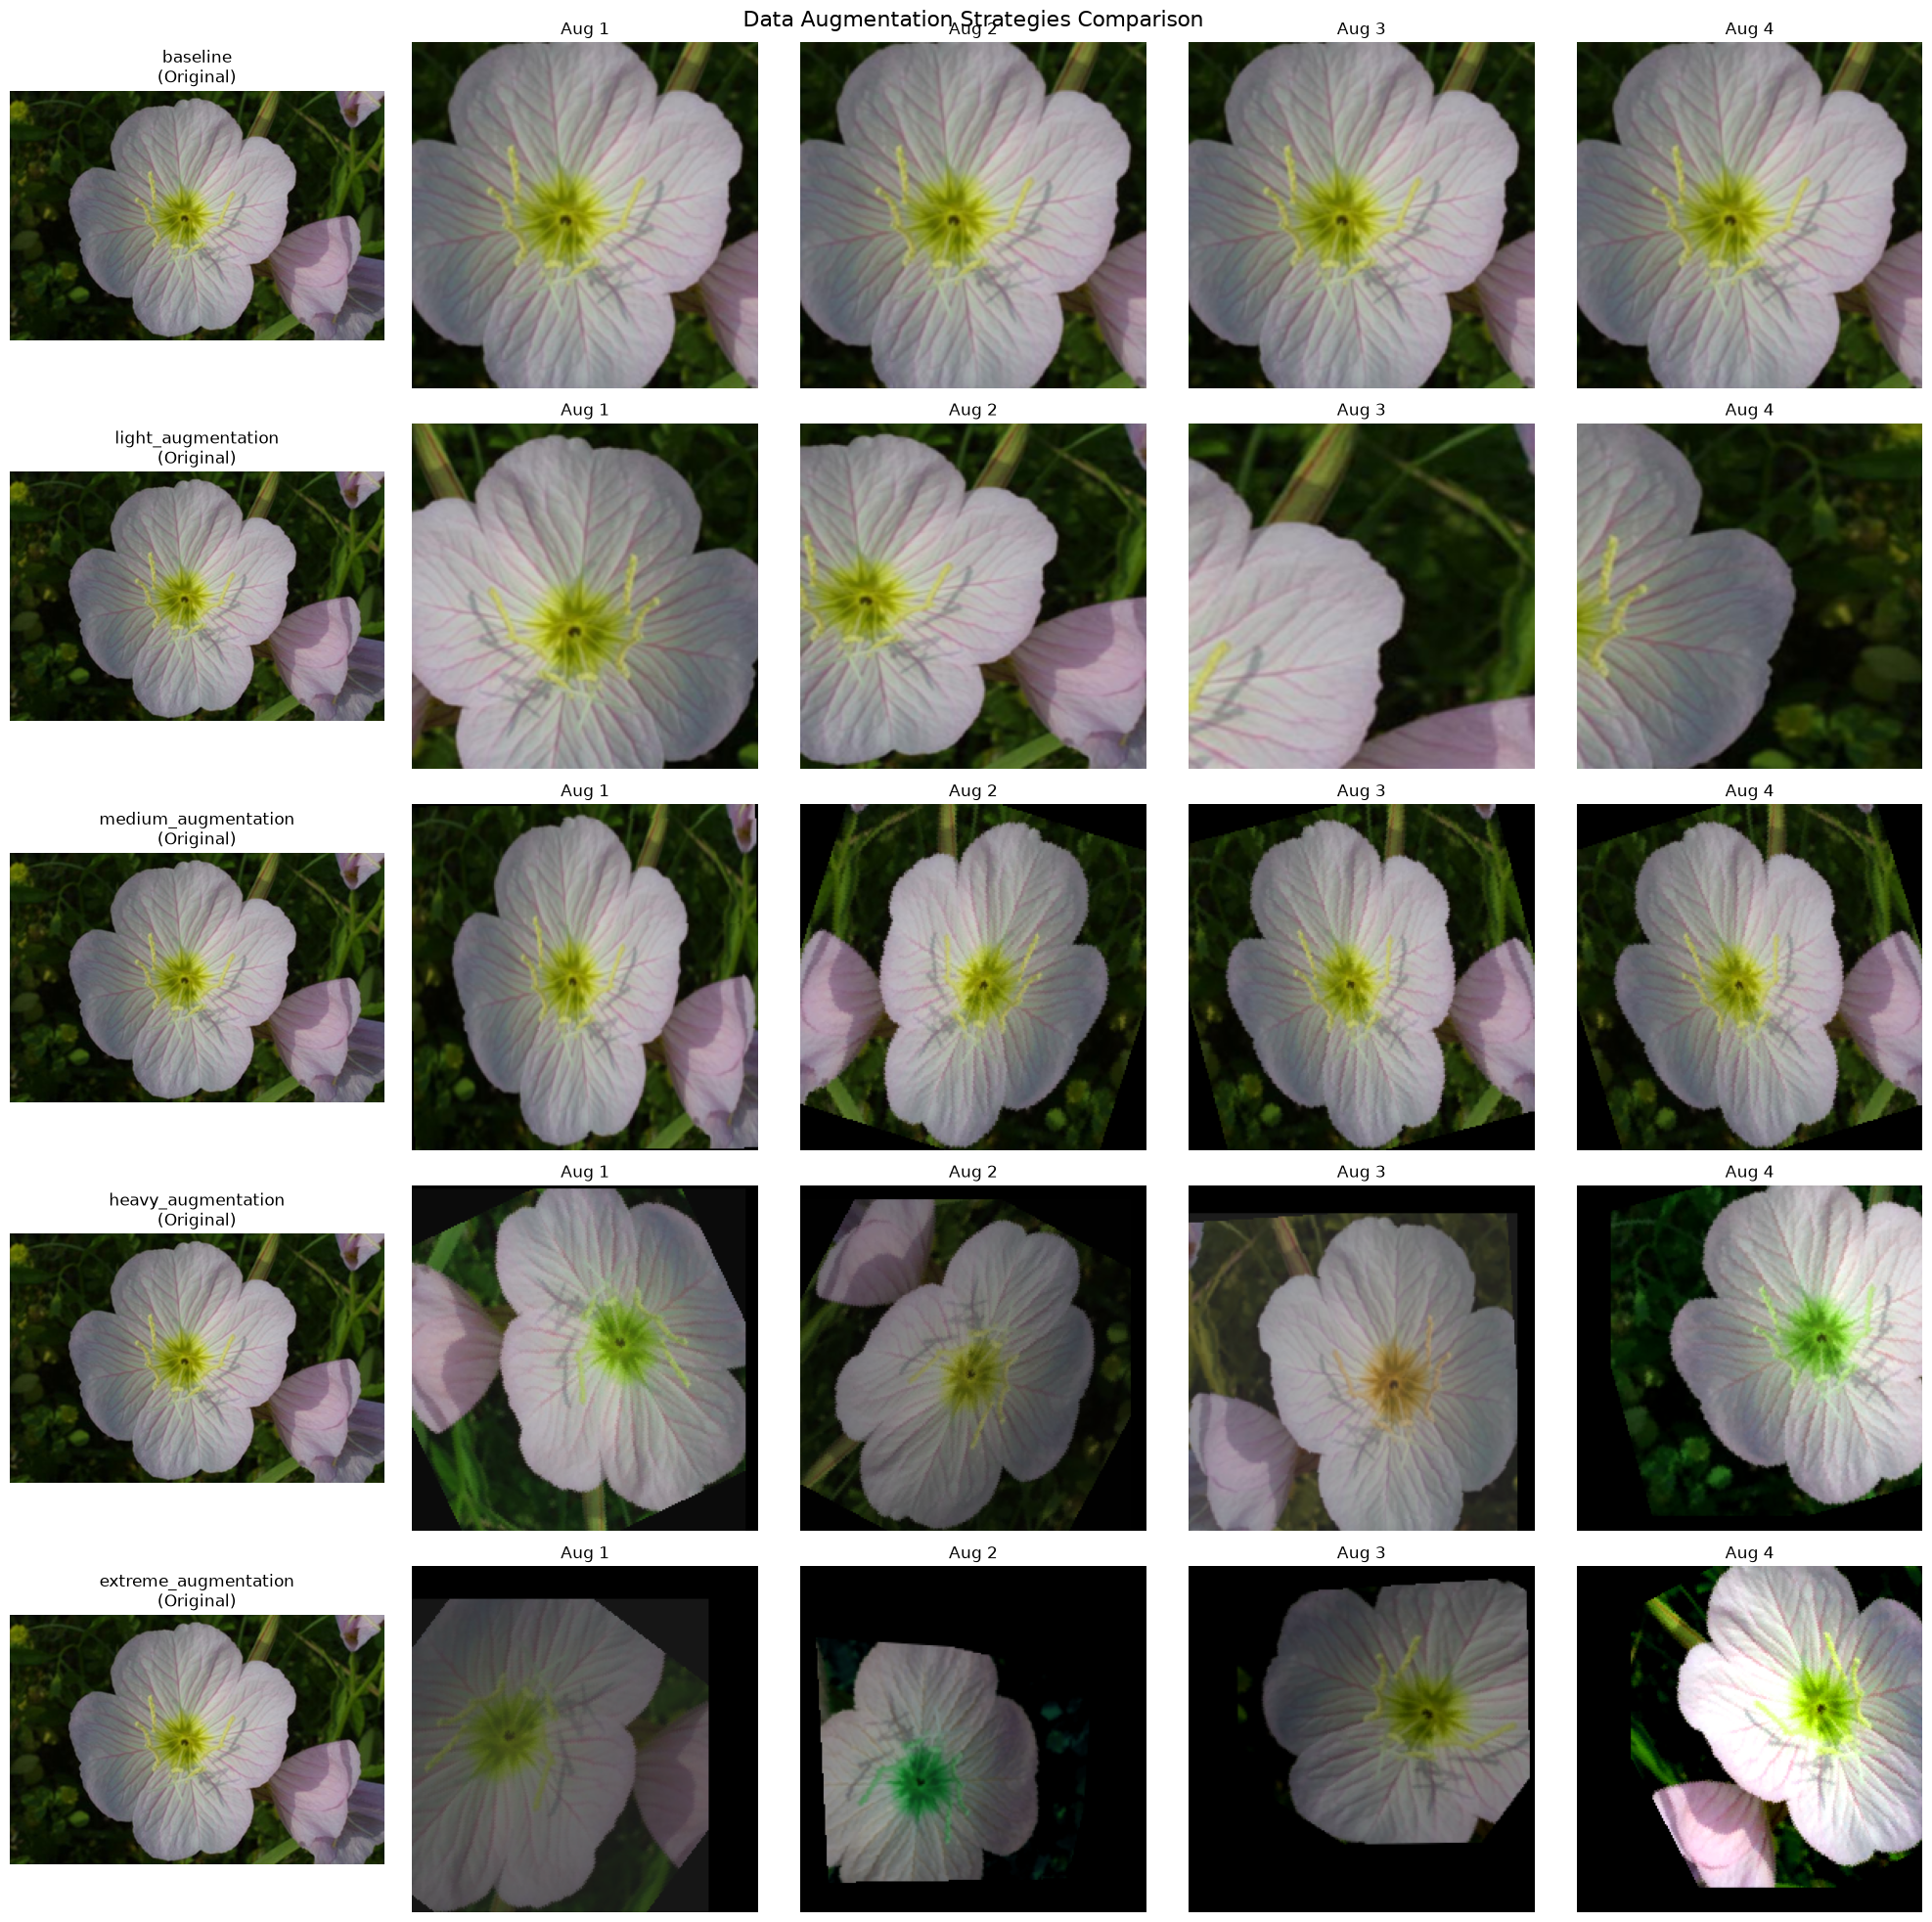

In [3]:
from PIL import Image

# Visualize augmentation effects
def visualize_augmentations(augmentation_strategies, sample_image_path, num_examples=4):
    """Visualize the effect of different augmentations"""
    fig, axes = plt.subplots(len(augmentation_strategies), num_examples + 1, figsize=(20, 4*len(augmentation_strategies)))
    
    for row, (strategy_name, transform) in enumerate(augmentation_strategies.items()):
        # Display original
        original = Image.open(sample_image_path)
        axes[row, 0].imshow(original)
        axes[row, 0].set_title(f'{strategy_name}\n(Original)')
        axes[row, 0].axis('off')
        
        # Display augmented versions
        for col in range(1, num_examples + 1):
            augmented = transform(original)
            # Denormalize for visualization
            augmented = augmented * torch.tensor(STD).view(3, 1, 1) + torch.tensor(MEAN).view(3, 1, 1)
            augmented = augmented.permute(1, 2, 0).numpy()
            augmented = np.clip(augmented, 0, 1)
            axes[row, col].imshow(augmented)
            axes[row, col].set_title(f'Aug {col}')
            axes[row, col].axis('off')
    
    plt.suptitle('Data Augmentation Strategies Comparison', fontsize=16)
    plt.tight_layout()
    plt.show()

# Get a sample image
sample_image_path = next((DATA_DIR / 'train' / '1').glob('*.jpg'))
# Ensure every augmentation receives a tensor, which is required by
# transforms such as RandomErasing.
tensor_first_strategies = {
    name: transforms.Compose([transforms.ToTensor(), transform])
    for name, transform in augmentation_strategies.items()
}

visualize_augmentations(
    augmentation_strategies,
    sample_image_path,
    num_examples=4
)

In [4]:
# Train model with different augmentation strategies
def train_with_augmentation(augmentation_name, transform, num_epochs=5):
    """Train a model with specific augmentation strategy"""
    # Create dataset with augmentation
    train_dataset = ImageFolder(root=DATA_DIR / 'train', transform=transform)
    val_dataset = ImageFolder(root=DATA_DIR / 'val', transform=augmentation_strategies['baseline'])
    
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)
    
    # Create model (ResNet50 for speed)
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False
    model.fc = nn.Linear(2048, 102)
    model = model.to(device)
    
    # Setup training
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
    
    # Training loop
    train_losses = []
    val_accs = []
    
    print(f"\nTraining with {augmentation_name} augmentation...")
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
        
        train_losses.append(running_loss / len(train_loader))
        
        # Validation
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
        
        val_acc = correct / total
        val_accs.append(val_acc)
        
        print(f"  Epoch {epoch+1}/{num_epochs}: Loss={train_losses[-1]:.4f}, Val Acc={val_acc:.4f}")
    
    return train_losses, val_accs

# Train with different strategies
results = {}
for strategy_name in ['baseline', 'light_augmentation', 'medium_augmentation', 'heavy_augmentation']:
    train_losses, val_accs = train_with_augmentation(
        strategy_name, 
        augmentation_strategies[strategy_name],
        num_epochs=5
    )
    results[strategy_name] = {
        'train_losses': train_losses,
        'val_accs': val_accs
    }


Training with baseline augmentation...
  Epoch 1/5: Loss=4.5060, Val Acc=0.4255
  Epoch 2/5: Loss=2.4627, Val Acc=0.6333
  Epoch 3/5: Loss=1.4086, Val Acc=0.7618
  Epoch 4/5: Loss=0.8641, Val Acc=0.7765
  Epoch 5/5: Loss=0.5467, Val Acc=0.8284

Training with light_augmentation augmentation...
  Epoch 1/5: Loss=4.7463, Val Acc=0.3059
  Epoch 2/5: Loss=3.1872, Val Acc=0.5049
  Epoch 3/5: Loss=2.2028, Val Acc=0.7020
  Epoch 4/5: Loss=1.5901, Val Acc=0.7647
  Epoch 5/5: Loss=1.2694, Val Acc=0.7971

Training with medium_augmentation augmentation...
  Epoch 1/5: Loss=4.6501, Val Acc=0.2275
  Epoch 2/5: Loss=2.9851, Val Acc=0.5206
  Epoch 3/5: Loss=2.0748, Val Acc=0.5569
  Epoch 4/5: Loss=1.4478, Val Acc=0.6363
  Epoch 5/5: Loss=1.0720, Val Acc=0.7255

Training with heavy_augmentation augmentation...
  Epoch 1/5: Loss=4.8357, Val Acc=0.1843
  Epoch 2/5: Loss=3.4340, Val Acc=0.4167
  Epoch 3/5: Loss=2.6048, Val Acc=0.5294
  Epoch 4/5: Loss=2.1079, Val Acc=0.5971
  Epoch 5/5: Loss=1.6638, Val 

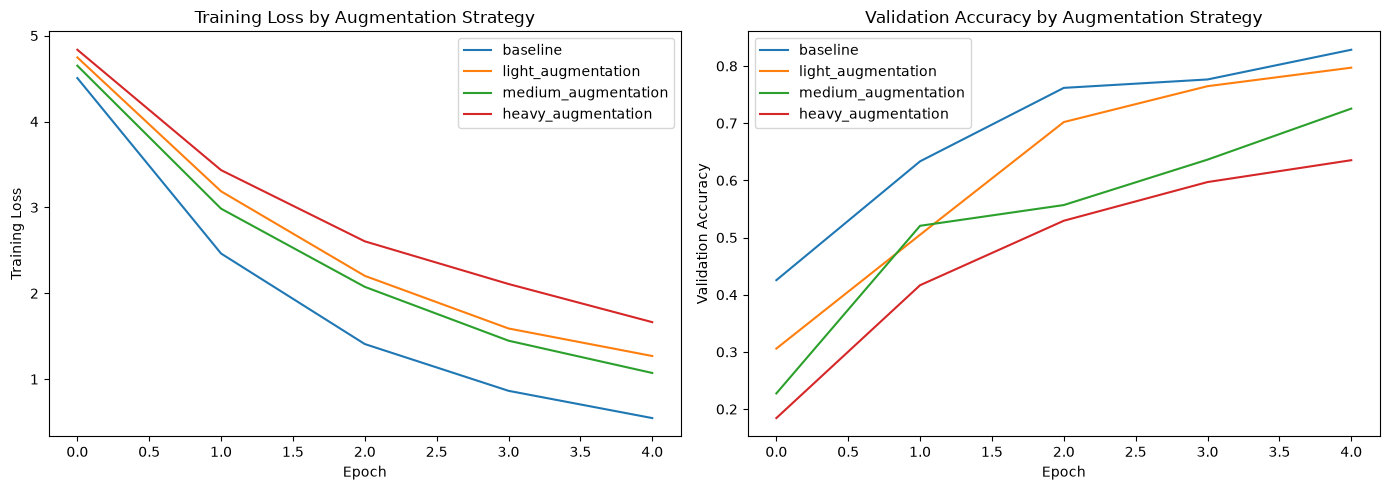

AUGMENTATION EXPERIMENT SUMMARY
baseline            : Best Val Acc = 0.8284
light_augmentation  : Best Val Acc = 0.7971
medium_augmentation : Best Val Acc = 0.7255
heavy_augmentation  : Best Val Acc = 0.6353


In [5]:
# Compare results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for strategy_name, result in results.items():
    ax1.plot(result['train_losses'], label=strategy_name)
    ax2.plot(result['val_accs'], label=strategy_name)

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss')
ax1.set_title('Training Loss by Augmentation Strategy')
ax1.legend()

ax2.set_xlabel('Epoch')
ax2.set_ylabel('Validation Accuracy')
ax2.set_title('Validation Accuracy by Augmentation Strategy')
ax2.legend()

plt.tight_layout()
plt.show()

# Summary
print("=" * 60)
print("AUGMENTATION EXPERIMENT SUMMARY")
print("=" * 60)
for strategy_name, result in results.items():
    best_acc = max(result['val_accs'])
    print(f"{strategy_name:20s}: Best Val Acc = {best_acc:.4f}")
print("=" * 60)